# H1 — Difference-in-Differences with CUPED

**Hypothesis:** Steam seasonal sales cause a net-positive review velocity lift in the 30 days following the sale.

**Method:** 2×2 DiD with CUPED variance reduction. Treatment proxy: games currently discounted in SteamSpy (May 2026 snapshot). Outcome: log review count during/after the Winter 2024 sale vs. 30-day pre-period.

In [1]:
import os, json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv
import psycopg

sys.path.insert(0, str(Path("..").resolve()))
from src.analysis.did import simple_did, did_with_cuped, permutation_test
from src.analysis.cuped import cuped_adjust, variance_reduction

load_dotenv()
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
conn = psycopg.connect(os.environ["DATABASE_URL"])
print("Connected.")


Connected.


## 1. Load treatment/control panel

In [2]:
tc = pd.read_parquet(RESULTS / "eda_treatment_control.parquet")
print(f"Total units: {len(tc):,}")
print(f"Treated: {tc['treated'].sum():,}  Control: {(~tc['treated']).sum():,}")
tc[["pre_reviews","sale_reviews","post_reviews","log_lift","treated"]].describe().round(2)


Total units: 2,185
Treated: 232  Control: 1,953


,pre_reviews,sale_reviews,post_reviews,log_lift
count,2185.00,2185.00,2185.00,2185.00
mean,721.00,1148.51,642.58,-0.10
std,2380.02,3766.08,2101.66,0.43
min,0.00,0.00,0.00,-1.10
25%,86.00,136.00,75.00,-0.19
50%,201.00,318.00,179.00,-0.13
75%,540.00,860.00,482.00,-0.06
max,66953.00,104995.00,58815.00,8.61


## 2. Naïve estimate vs DiD

In [3]:
tc["log_pre"]  = np.log1p(tc["pre_reviews"])
tc["log_post"] = np.log1p(tc["post_reviews"])

naive = simple_did(tc, "log_pre", "log_post", "treated")
print("=== Naïve DiD (no CUPED) ===")
print(f"  ATT:  {naive['att']:+.4f}")
print(f"  SE:   {naive['se']:.4f}")
print(f"  95%CI: [{naive['ci_low']:+.4f}, {naive['ci_high']:+.4f}]")
print(f"  Treated Δ: {naive['delta_treated']:+.4f}  Control Δ: {naive['delta_control']:+.4f}")


=== Naïve DiD (no CUPED) ===
  ATT:  -0.0275
  SE:   0.1622
  95%CI: [-0.3454, +0.2903]
  Treated Δ: -0.1249  Control Δ: -0.0974


## 3. CUPED-adjusted DiD

In [4]:
result = did_with_cuped(tc, "log_pre", "log_post", "treated")

print("=== CUPED-adjusted DiD ===")
print(f"  ATT:  {result['cuped_att']:+.4f}")
print(f"  SE:   {result['cuped_se']:.4f}")
print(f"  95%CI: [{result['cuped_ci_low']:+.4f}, {result['cuped_ci_high']:+.4f}]")
print(f"  theta (CUPED coefficient): {result['theta']:.4f}")
print(f"  Variance reduction: {result['variance_reduction']:.1%}")
print(f"  SE reduction: {1 - result['cuped_se']/result['naive_se']:.1%}")
sig = "SIGNIFICANT" if result['cuped_ci_low'] > 0 or result['cuped_ci_high'] < 0 else "not significant"
print(f"  Result: {sig} at 95% confidence")


=== CUPED-adjusted DiD ===
  ATT:  -0.0317
  SE:   0.0165
  95%CI: [-0.0641, +0.0007]
  theta (CUPED coefficient): 0.9479
  Variance reduction: 94.2%
  SE reduction: 89.8%
  Result: not significant at 95% confidence


## 4. Parallel trends plot

C:\Users\divye\AppData\Local\Temp\ipykernel_7864\3948131334.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly = pd.read_sql("""


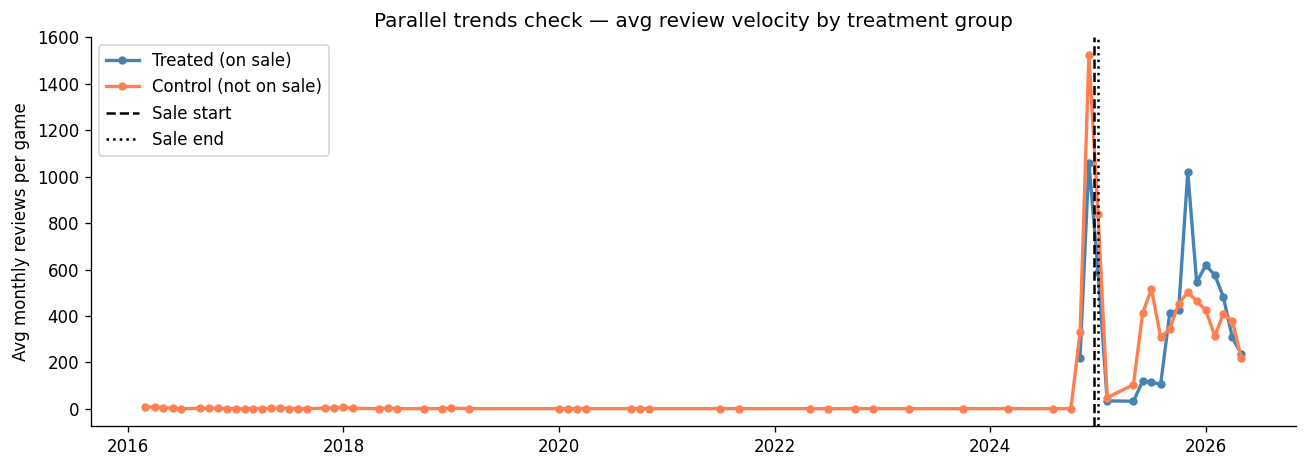

If lines move together before Dec 2024, the parallel-trends assumption is credible.


In [5]:
import datetime as dt

monthly = pd.read_sql("""
    SELECT
        DATE_TRUNC('month', review_date)::DATE AS month,
        appid,
        SUM(review_count) AS monthly_reviews
    FROM mart.fct_reviews_daily
    GROUP BY 1, 2
""", conn, parse_dates=["month"])

monthly_agg = (
    monthly
    .merge(tc[["appid","treated"]], on="appid")
    .groupby(["month","treated"])["monthly_reviews"]
    .mean()
    .reset_index()
    .rename(columns={"monthly_reviews": "avg_reviews"})
)

fig, ax = plt.subplots(figsize=(11, 4))
for treated_val, label, color in [(True, "Treated (on sale)", "steelblue"),
                                   (False, "Control (not on sale)", "coral")]:
    d = monthly_agg[monthly_agg["treated"] == treated_val]
    ax.plot(d["month"], d["avg_reviews"], label=label, color=color, lw=2, marker="o", ms=4)

ax.axvline(pd.Timestamp("2024-12-19"), color="black", ls="--", lw=1.5, label="Sale start")
ax.axvline(pd.Timestamp("2025-01-02"), color="black", ls=":",  lw=1.5, label="Sale end")
ax.set_ylabel("Avg monthly reviews per game")
ax.set_title("Parallel trends check — avg review velocity by treatment group")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_did_parallel_trends.png", dpi=150)
plt.show()
print("If lines move together before Dec 2024, the parallel-trends assumption is credible.")


## 5. Permutation test (randomisation inference)

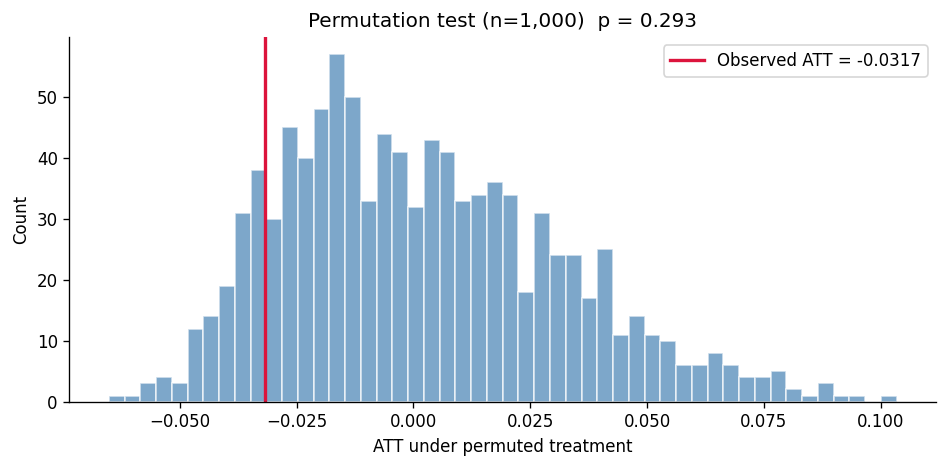

Two-sided p-value: 0.293


In [6]:
perm = permutation_test(tc, "log_pre", "log_post", "treated",
                        n_permutations=1000, seed=42)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm["null_distribution"], bins=50, color="steelblue", edgecolor="white", alpha=0.7)
ax.axvline(perm["observed_att"], color="crimson", lw=2,
           label=f"Observed ATT = {perm['observed_att']:+.4f}")
ax.set_xlabel("ATT under permuted treatment")
ax.set_ylabel("Count")
ax.set_title(f"Permutation test (n=1,000)  p = {perm['p_value']:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_did_permutation.png", dpi=150)
plt.show()
print(f"Two-sided p-value: {perm['p_value']:.3f}")


## 6. Heterogeneity by game tier

In [7]:
for tier, mask_col in [("Indie", "is_indie"), ("AAA", "is_aaa")]:
    sub = tc[tc[mask_col] == True].copy() if mask_col in tc.columns else tc.copy()
    if len(sub[sub["treated"]]) < 5:
        print(f"{tier}: too few treated ({len(sub[sub['treated']])}) — skipping")
        continue
    r = did_with_cuped(sub, "log_pre", "log_post", "treated")
    print(f"{tier:6s}  ATT={r['cuped_att']:+.4f}  SE={r['cuped_se']:.4f}  "
          f"CI=[{r['cuped_ci_low']:+.4f}, {r['cuped_ci_high']:+.4f}]  "
          f"VR={r['variance_reduction']:.1%}  n_t={r['n_treated']}")


Indie   ATT=-0.0146  SE=0.0315  CI=[-0.0764, +0.0472]  VR=94.0%  n_t=87
AAA     ATT=-0.0496  SE=0.0308  CI=[-0.1101, +0.0108]  VR=89.7%  n_t=74


## 7. Save results

In [8]:
h1_results = {
    "naive_att":  result["naive_att"],
    "naive_se":   result["naive_se"],
    "cuped_att":  result["cuped_att"],
    "cuped_se":   result["cuped_se"],
    "cuped_ci_low":  result["cuped_ci_low"],
    "cuped_ci_high": result["cuped_ci_high"],
    "variance_reduction": result["variance_reduction"],
    "permutation_p": perm["p_value"],
    "n_treated": result["n_treated"],
    "n_control": result["n_control"],
}
with open(RESULTS / "h1_did_results.json", "w") as f:
    json.dump(h1_results, f, indent=2)
print(json.dumps(h1_results, indent=2))
conn.close()


{
  "naive_att": -0.027516646975682235,
  "naive_se": 0.1621649637503535,
  "cuped_att": -0.03169629486360925,
  "cuped_se": 0.016543959774359154,
  "cuped_ci_low": -0.06412245602135319,
  "cuped_ci_high": 0.0007298662941346845,
  "variance_reduction": 0.9417262597898532,
  "permutation_p": 0.293,
  "n_treated": 232,
  "n_control": 1953
}
